# Worked Example: Artifact Pass on Bipolar Continuous Data

## Goal
Run misc + IED detectors on `sample_ieeg_bp.fif` and plot flagged time ranges.


In [1]:
from pathlib import Path
from LFPAnalysis import build_basic_pipeline_config, run_pipeline

config = build_basic_pipeline_config(
    Path('../../data/sample_ieeg_bp.fif'),
    file_format='mne',
    artifact_methods=['misc', 'ied'],
    preload=True,
)
result = run_pipeline(config)
misc_table = result.artifact_tables['misc']
ied_table = result.artifact_tables['ied']
print(f'Misc events: {len(misc_table)}, IED events: {len(ied_table)}')
print(misc_table.head())

Opening raw data file /Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif...
    Range : 0 ... 394061 =      0.000 ...   788.122 secs
Ready.
Reading 0 ... 394061  =      0.000 ...   788.122 secs...


/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/LFPAnalysis/workflow.py:146: RuntimeWarning: This filename (/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  data = mne.io.read_raw_fif(path, preload=config.preload)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 25 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 25.00
- Lower transition bandwidth: 6.25 Hz (-6 dB cutoff frequency: 21.88 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 265 samples (0.530 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:    1.4s remaining:    3.9s
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    1.5s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  12 out of  15 | elapsed:    1.6s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:    0.1s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  15 | elapsed:    0.2s remaining:    0.0s


Misc events: 1930, IED events: 0
  event_kind        channel  time_seconds  sample_index
0       misc  racas1-racas2       294.742        147371
1       misc  racas1-racas2       738.560        369280
2       misc  racas2-racas3       788.084        394042
3       misc  racas2-racas3       788.086        394043
4       misc  racas3-racas4       788.084        394042


[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    0.4s finished


## Plot flagged time ranges on a short raw segment

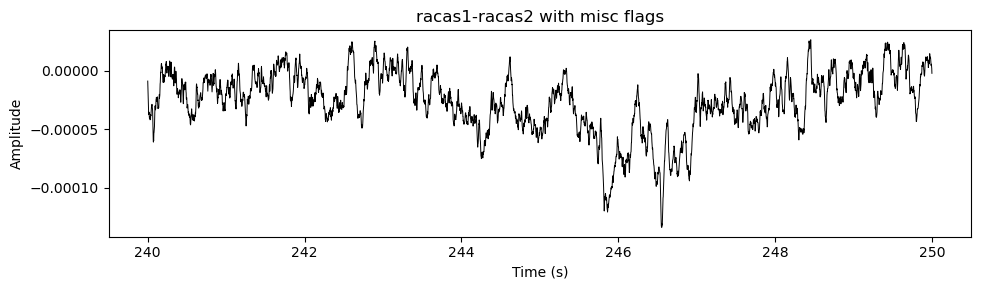

In [2]:
import matplotlib.pyplot as plt
import numpy as np

raw = result.referenced if result.referenced is not None else result.raw
chan = 'racas1-racas2' if 'racas1-racas2' in raw.ch_names else raw.ch_names[0]
sfreq = float(raw.info['sfreq'])
t0, t1 = 240.0, 250.0
start, stop = int(t0 * sfreq), int(t1 * sfreq)
segment = raw.get_data(picks=[chan])[0, start:stop]
times = np.arange(len(segment)) / sfreq + t0
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(times, segment, 'k', lw=0.7)
chan_events = misc_table[misc_table['channel'] == chan] if len(misc_table) else misc_table
for _, row in chan_events.iterrows():
    t = float(row['time_seconds'])
    if t0 <= t <= t1:
        ax.axvspan(t - 0.05, t + 0.05, color='C1', alpha=0.35)
ax.set(xlabel='Time (s)', ylabel='Amplitude', title=f'{chan} with misc flags')
fig.tight_layout()
plt.show()

## Saving results

See chapter 15 (`15_saving_and_organizing_results`) for the recommended `results/` layout.

In [ ]:
# Uncomment to save. See chapter 15 for the recommended results/ layout.
# out = Path('../../results/worked-examples')
# out.mkdir(parents=True, exist_ok=True)
# misc_table.to_csv(out / 'misc_artifacts.csv', index=False)
# ied_table.to_csv(out / 'ied_artifacts.csv', index=False)

## Next step

Chapter 07 (`07_first_event_locked_workflow`) covers event-locked epochs and baselining.
